In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator

In [2]:
def bin_singlelc(t,y,yerr, Ninbin):
    ## function to bin a light curve
    counter = 0
    # see how many points we need
    void = []
    while counter < len(t):
        void.append(-99)
        counter += Ninbin
    Nlen = len(void)

    counter = 0
    icounter = 0
    tb = np.zeros(Nlen)
    yb = np.zeros(Nlen)
    yerrb = np.zeros(Nlen)
    while counter < len(t):
        t_inbin = t[counter:counter+Ninbin]
        y_inbin = y[counter:counter+Ninbin]
        yerr_inbin = yerr[counter:counter+Ninbin]

        bin_t = np.nanmedian(t_inbin)
        bin_y = np.nanmedian(y_inbin)
        bin_yerr = np.nanmedian(yerr_inbin) / np.sqrt(Ninbin)

        tb[icounter] = bin_t
        yb[icounter] = bin_y
        yerrb[icounter] = bin_yerr

        counter += Ninbin
        icounter += 1
    return tb, yb, yerrb

In [3]:
## -- load in data from curated npz files
## -- each has light curve data and best-fit models for each case
## -- we'll also bin each light curve for nice plotting

Nbin = 23 # number of points in each bin

## -- case 1
l1 = np.load('./data/broadband_readysave_case1.npz')

t1 = l1['t'] # time
y1 = l1['y'] # relative flux
yerr1 = l1['yerr'] # relative flux uncertainty
tm1 = l1['tm'] # transit model
sm1 = l1['sys'] # systematics model (polynomial)
fm1 = l1['fm'] # 'full model' (transit * systematics)
tnomask1 = l1['t_nomask'] # time sans mask
ynomask1 = l1['y_nomask'] # rel. flux sans mask
smnomask1 = l1['sys_nomask'] # sys. model sans mask
dy1 = y1 / sm1 # detrended flux
dynomask1 = ynomask1 / smnomask1 # ... sans mask
res1 = y1 - fm1 # residuals
tb1, dyb1, yerrb1 = bin_singlelc(t1, dy1, yerr1, Nbin) # binned LCs
void, resb1, void = bin_singlelc(t1, res1, yerr1, Nbin) # binned residual LC
del l1

# these are the integrations that are masked
sce1s, sce1e = 658, 850
sce2s, sce2e = 970,1300
sce3s, sce3e = 1370,1450
sce4s, sce4e = 1550, 1700
sce_idxs = np.concatenate((np.arange(sce1s,sce1e),np.arange(sce2s,sce2e),np.arange(sce3s,sce3e),np.arange(sce4s,sce4e)))


## -- case 2
l2 = np.load('./data/broadband_readysave_case2.npz')

t2 = l2['t']
y2 = l2['y']
yerr2 = l2['yerr']
tm2 = l2['tm']
sm2 = l2['sys']
scm2 = l2['scm'] # spot model
fm2 = l2['fm']
dy2 = y2 / sm2
res2 = y2 - fm2
tb2, dyb2, yerrb2 = bin_singlelc(t2, dy2, yerr2, Nbin)
void, resb2, void = bin_singlelc(t2, res2, yerr2, Nbin)

## -- case 3
l3 = np.load('./data/broadband_readysave_case3.npz')

t3 = l3['t']
y3 = l3['y']
yerr3 = l3['yerr']
tm3 = l3['tm']
sm3 = l3['sys']
fm3 = l3['fm']
dy3 = y3 / sm3
res3 = y3 - fm3
tb3, dyb3, yerrb3 = bin_singlelc(t3, dy3, yerr3, Nbin)
void, resb3, void = bin_singlelc(t3, res3, yerr3, Nbin)

## -- case 4
l4 = np.load('./data/broadband_readysave_case4.npz')

t4 = l4['t']
y4 = l4['y']
yerr4 = l4['yerr']
tm4 = l4['tm']
sm4 = l4['sys']
gpm4 = l4['gp'] # GP model
fm4 = l4['fm']
dy4 = y4 / sm4
res4 = y4 - fm4
tb4, dyb4, yerrb4 = bin_singlelc(t4, dy4, yerr4, Nbin)
void, resb4, void = bin_singlelc(t4, res4, yerr4, Nbin)


In [4]:
## -- colors to use in plot:
c1 = '#0652FF'
c2 = 'green'
c3 = '#6DADE2'
c4 = '#FFAB0F'

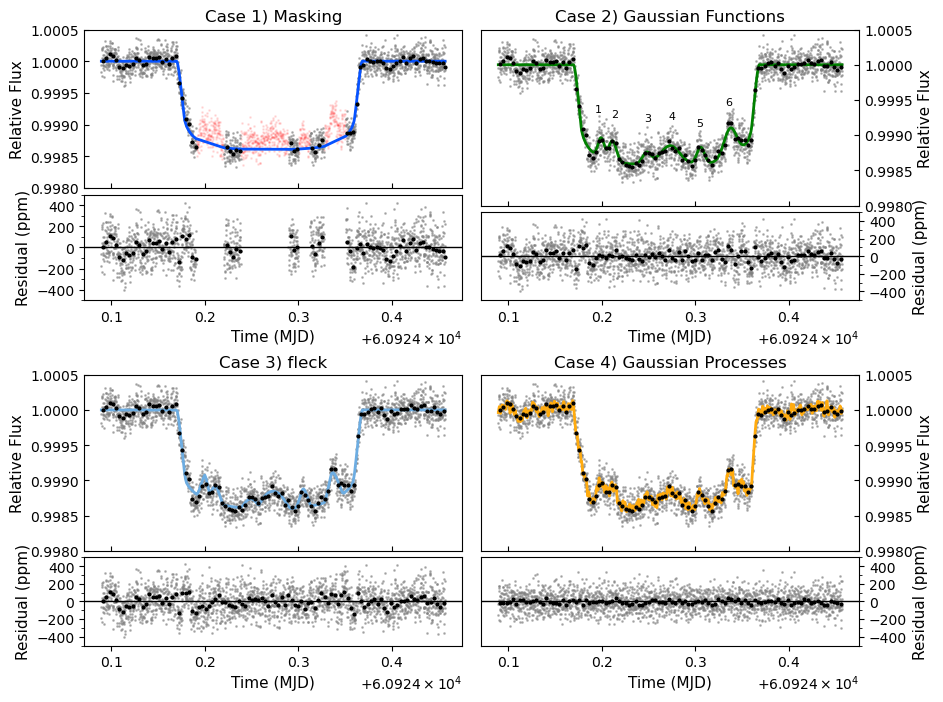

In [5]:
## figure 2:

fig = plt.figure(figsize=(10, 8))
# Main 2x2 grid
gs = GridSpec(2, 2, figure=fig, wspace=0.05, hspace=0.275)
# ---- Upper-left panel ----
gs_ul = gs[0, 0].subgridspec(2, 1, height_ratios=[1.5, 1], hspace=0.05)
ax_ul_top = fig.add_subplot(gs_ul[0])
ax_ul_bot = fig.add_subplot(gs_ul[1], sharex=ax_ul_top)
ax_ul_top.tick_params(labelbottom=False, bottom=True, direction='in')
ax_ul_top.set_title("Case 1) Masking")

ax_ul_top.plot(tnomask1[sce_idxs], dynomask1[sce_idxs], ls='None', marker='o', ms=1, c='red', alpha=0.1, zorder=1)
ax_ul_top.plot(t1, dy1, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=2)
ax_ul_top.plot(tb1, dyb1, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_ul_top.plot(t1, tm1, lw=2, c=c1)
ax_ul_top.set_ylim(0.9980, 1.0005)
ax_ul_top.set_ylabel("Relative Flux", fontsize=11)

ax_ul_bot.plot(t1, res1*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1)
ax_ul_bot.plot(tb1, resb1*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_ul_bot.axhline(0., c='black', lw=1)
ax_ul_bot.yaxis.set_major_locator(MultipleLocator(200)); ax_ul_bot.yaxis.set_minor_locator(MultipleLocator(100))
ax_ul_bot.set_ylabel("Residual (ppm)", fontsize=11)
ax_ul_bot.set_xlabel("Time (MJD)", fontsize=11)
ax_ul_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_ul_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_ul_bot.set_ylim(-500,500)

# ---- Upper-right panel ----
gs_ur = gs[0, 1].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_ur_top = fig.add_subplot(gs_ur[0])
ax_ur_bot = fig.add_subplot(gs_ur[1], sharex=ax_ur_top)
ax_ur_top.tick_params(labelbottom=False, bottom=True, direction='in')
ax_ur_top.yaxis.set_label_position("right"); ax_ur_top.yaxis.tick_right()
ax_ur_bot.yaxis.set_label_position("right"); ax_ur_bot.yaxis.tick_right()
ax_ur_top.set_title("Case 2) Gaussian Functions")

ax_ur_top.plot(t2, dy2, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1)
ax_ur_top.plot(tb2, dyb2, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_ur_top.plot(t2, (tm2*scm2), lw=2, c=c2)
ax_ur_top.set_ylim(0.9980, 1.0005)
ax_ur_top.set_ylabel("Relative Flux", fontsize=11)

ax_ur_bot.plot(t2, res2*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1)
ax_ur_bot.plot(tb2, resb2*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_ur_bot.axhline(0., c='black', lw=1)
ax_ur_bot.yaxis.set_major_locator(MultipleLocator(200)); ax_ur_bot.yaxis.set_minor_locator(MultipleLocator(100))
ax_ur_bot.set_ylabel("Residual (ppm)", fontsize=11)
ax_ur_bot.set_xlabel("Time (MJD)", fontsize=11)
ax_ur_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_ur_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_ur_bot.set_ylim(-500,500)

# ---- Lower-left panel ----
gs_ll = gs[1, 0].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_ll_top = fig.add_subplot(gs_ll[0])
ax_ll_bot = fig.add_subplot(gs_ll[1], sharex=ax_ll_top)
ax_ll_top.tick_params(labelbottom=False, bottom=True, direction='in')
ax_ll_top.set_title("Case 3) fleck")

ax_ll_top.plot(t3, dy3, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1)
ax_ll_top.plot(tb3, dyb3, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_ll_top.plot(t3, (tm3), lw=2, c=c3)
ax_ll_top.set_ylim(0.9980, 1.0005)
ax_ll_top.set_ylabel("Relative Flux", fontsize=11)

ax_ll_bot.plot(t3, res3*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1)
ax_ll_bot.plot(tb3, resb3*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_ll_bot.axhline(0., c='black', lw=1)
ax_ll_bot.yaxis.set_major_locator(MultipleLocator(200)); ax_ll_bot.yaxis.set_minor_locator(MultipleLocator(100))
ax_ll_bot.set_ylabel("Residual (ppm)", fontsize=11)
ax_ll_bot.set_xlabel("Time (MJD)", fontsize=11)
ax_ll_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_ll_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_ll_bot.set_ylim(-500,500)

# ---- Lower-right panel ----
gs_lr = gs[1, 1].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
ax_lr_top = fig.add_subplot(gs_lr[0])
ax_lr_bot = fig.add_subplot(gs_lr[1], sharex=ax_lr_top)
ax_lr_top.tick_params(labelbottom=False, bottom=True, direction='in')
ax_lr_top.yaxis.set_label_position("right"); ax_lr_top.yaxis.tick_right()
ax_lr_bot.yaxis.set_label_position("right"); ax_lr_bot.yaxis.tick_right()
ax_lr_top.set_title("Case 4) Gaussian Processes")

ax_lr_top.plot(t4, dy4, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1)
ax_lr_top.plot(tb4, dyb4, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_lr_top.plot(t4, (tm4+gpm4), lw=2, c=c4)
ax_lr_top.set_ylim(0.9980, 1.0005)
ax_lr_top.set_ylabel("Relative Flux", fontsize=11)

ax_lr_bot.plot(t4, res4*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1)
ax_lr_bot.plot(tb4, resb4*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5)
ax_lr_bot.axhline(0., c='black', lw=1)
ax_lr_bot.yaxis.set_major_locator(MultipleLocator(200)); ax_lr_bot.yaxis.set_minor_locator(MultipleLocator(100))
ax_lr_bot.set_ylabel("Residual (ppm)", fontsize=11)
ax_lr_bot.set_xlabel("Time (MJD)", fontsize=11)
ax_lr_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_lr_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_lr_bot.set_ylim(-500,500)


ax_ur_top.text(0.30, 0.53, '1', c='black', fontsize=8, transform=ax_ur_top.transAxes)
ax_ur_top.text(0.345, 0.5, '2', c='black', fontsize=8, transform=ax_ur_top.transAxes)
ax_ur_top.text(0.43, 0.48, '3', c='black', fontsize=8, transform=ax_ur_top.transAxes)
ax_ur_top.text(0.495, 0.49, '4', c='black', fontsize=8, transform=ax_ur_top.transAxes)
ax_ur_top.text(0.57, 0.45, '5', c='black', fontsize=8, transform=ax_ur_top.transAxes)
ax_ur_top.text(0.645, 0.57, '6', c='black', fontsize=8, transform=ax_ur_top.transAxes)

plt.savefig('./figures/Figure2.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure2.pdf', format='PDF', dpi=600, bbox_inches='tight')
plt.show()